In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

In [15]:
x = 5 # int
y = 3.14 # float
name = "Alice" # str
is_student = True # bool
fruits = ["apple", "banana", "cherry"] # list
person = {"name": "Bob", "age": 25} # dict
array = np.array([1, 2, 3, 4, 5]) # numpy array

print(type(x))          # <class 'int'>
print(type(y))          # <class 'float'>
print(type(name))       # <class 'str'>
print(type(is_student)) # <class 'bool'>
print(type(fruits))     # <class 'list'>
print(type(person))     # <class 'dict'>

<class 'int'>
<class 'float'>
<class 'str'>
<class 'bool'>
<class 'list'>
<class 'dict'>


In [5]:
fruits[0]
fruits[2]
person["name"]
person["age"]

25

In [6]:
#Check data file existence and type using os module
DATANAME = 'sample_data.csv'

print(DATANAME)
print(os.path.exists(DATANAME)) # Check if the data file exists
print(os.path.isfile(DATANAME)) # Check if it's a file
print(os.path.isdir(DATANAME))  # Check if it's a directory

current_dir = os.getcwd() #this gets your current working directory (the folder you are "in")
print(current_dir) # Print current working directory

images_dir = os.path.join(current_dir, 'images') # Create path for images directory, best practice to use os to join multiple paths
print(os.path.isdir(images_dir)) # Print images directory path

print(os.path.splitext(DATANAME))  # Get the file extension
print(os.path.splitext(DATANAME)[0])  # Get the file name without extension, references the 0th index of the splittext
print(os.path.splitext(DATANAME)[1])  # Get only the file extension, the 1st index of the tuple returned by splitext

#check data file existence and type using pathlib module using Path
print(Path()) #will current working directory as .
print(Path().resolve()) #will print the full path of the current working directory
print(Path(DATANAME)) # Check if the data file exists

f = Path(DATANAME).resolve() #assign the full path of the data file to variable f
print(type(f)) # Check the type of f, becomes a pathlib object
print(f.exists()) # Check if the data file exists similar to os.path.exists
print(f.is_file()) # Check if it's a file similar to os.path.isfile
print(f.is_dir())  # Check if it's a directory similar to os.path.isdir

images_dir_pathlib = Path() / 'images' # Path references cwd then use / to join multiple paths

print(Path(DATANAME).suffix)  # Get the file extension
print(Path(DATANAME).stem)    # Get the file name without extension

sample_data.csv
True
True
False
/Users/aniyahartzler/Documents/PythonTutorial
True
('sample_data', '.csv')
sample_data
.csv
.
/Users/aniyahartzler/Documents/PythonTutorial
sample_data.csv
<class 'pathlib._local.PosixPath'>
True
True
False
.csv
sample_data


In [ ]:
#read data using Pandas
DATANAME = 'sample_data.csv'
data_path = Path.cwd() / DATANAME
print(data_path.resolve()) #will print the full path of the current working directory
df = pd.read_csv(data_path) ## Pandas is smart: it can take a string OR a pathlib object directly 

# view df 
print(df.head()) #prints the first 5 rows of the data
print(df.info()) #prints a summary of the data
print(df.columns) #prints the column names
print(df.shape) #prints the rowsxcolumns 
print(df.shape[0]) # prints the 0th index of the shape
print(df.shape[1]) #prints the 1st index of the shape
print(f"This dataframe has {df.shape[0]} rows and {df.shape[1]} columns") #this is a formatted string, it allows you to call variables in a string for a cleaner code
print(df.describe()) #prints summary statistics of the data

#maybe this cell_count is actually cell_count per area and you want to figure out the total cells where 5 is the area of the culture plate in cm^2
df['Total_cell_count'] = df['Cell_Count']*5
df['hours'] = df['Day']*24
#the groupby function allows you to group a specific column (cell count) based on others (day + treatment)
summary = df.groupby(['Day', 'Group'])['Total_cell_count'].mean().reset_index(name='Avg_Total_Cell_Count') #reset index to turn the groupby object back to a dataframe
summary = df.groupby(['Day', 'Group'])['Total_cell_count'].agg(['mean', 'std', 'count']).reset_index() # alternative way to get mean and std
summary

   Day    Group  Cell_Count
0    1  Control          98
1    1  Control         102
2    1  Control         100
3    2  Control         118
4    2  Control         121
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Day         30 non-null     int64 
 1   Group       30 non-null     object
 2   Cell_Count  30 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 852.0+ bytes
None
Index(['Day', 'Group', 'Cell_Count'], dtype='object')
(30, 3)
30
3
This dataframe has 30 rows and 3 columns
            Day  Cell_Count
count  30.00000   30.000000
mean    3.00000  156.966667
std     1.43839   49.735496
min     1.00000   98.000000
25%     2.00000  120.250000
50%     3.00000  145.000000
75%     4.00000  179.500000
max     5.00000  262.000000


,Day,Group,mean,std,count
0,1,Control,500.000000,10.000000,3
1,1,Treatment,500.000000,5.000000,3
2,2,Control,598.333333,7.637626,3
3,2,Treatment,700.000000,10.000000,3
4,3,Control,675.000000,15.000000,3
5,3,Treatment,900.000000,10.000000,3
6,4,Control,750.000000,10.000000,3
7,4,Treatment,1100.000000,10.000000,3
8,5,Control,825.000000,10.000000,3
9,5,Treatment,1300.000000,10.000000,3


<Axes: xlabel='Day', ylabel='Total_cell_count'>

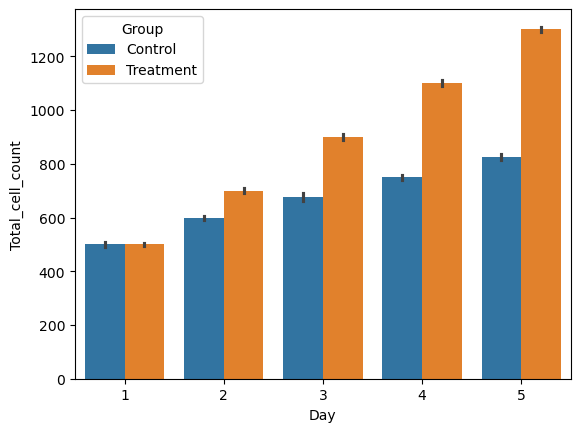

In [ ]:
#first bar plot of raw with error bars
sns.barplot(
    data=df,
    x='Day',
    y='Total_cell_count',
    hue='Group',
    errorbar='sd'
)

days = df['Day'].unique()
plt.xticks(days)
plt.xlabel("Day")
plt.ylabel("Mean Total Cell Count")
plt.title("Mean Cell Growth Over Time")
plt.show()

<Axes: xlabel='Day', ylabel='Total_cell_count'>

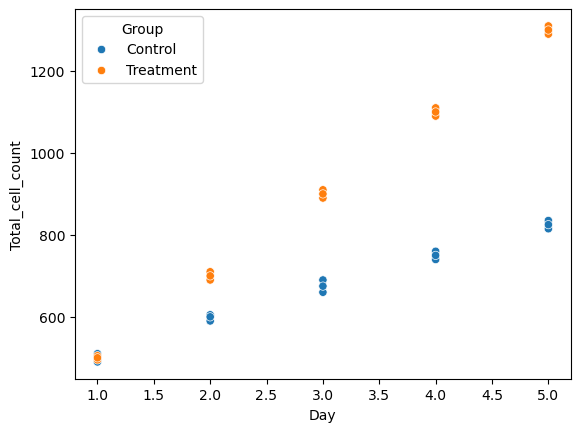

In [16]:
sns.scatterplot(
    data=df,
    x='Day',
    y='Total_cell_count',
    hue='Group', #hue separates so each treatment group has its own color
    markers='o',
    
)

<ErrorbarContainer object of 3 artists>

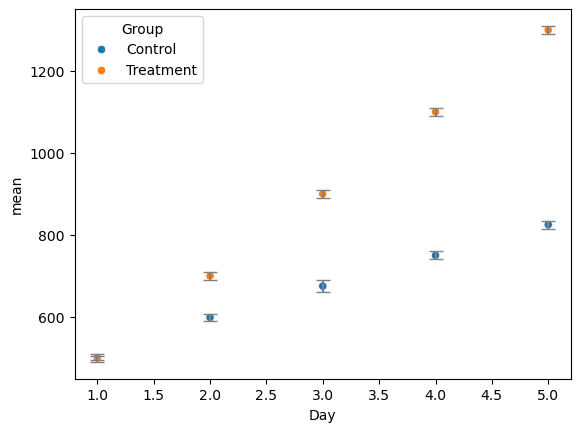

In [ ]:
sns.scatterplot(
    data=summary,
    x='Day',
    y='mean',
    hue='Group', 
)

plt.errorbar(
    data=summary,
    x='Day',
    y='mean',
    yerr=summary['std'],
    fmt='none',
    capsize=5,
    ecolor='gray',
)

#you can do the same thing with a line plot

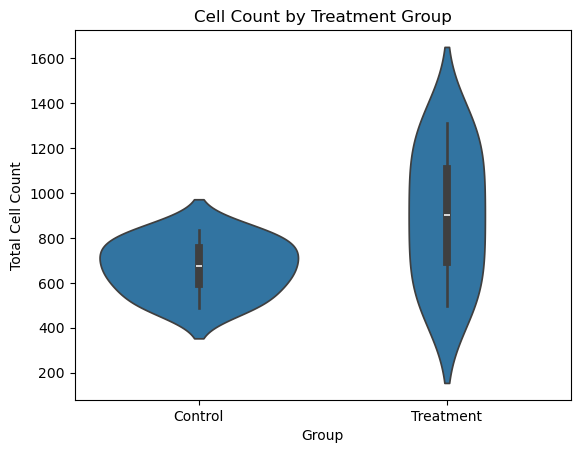

In [19]:
sns.violinplot(
    data=df,
    x='Group',
    y='Total_cell_count'
)

plt.xlabel("Group")
plt.ylabel("Total Cell Count")
plt.title("Cell Count by Treatment Group")
plt.show()

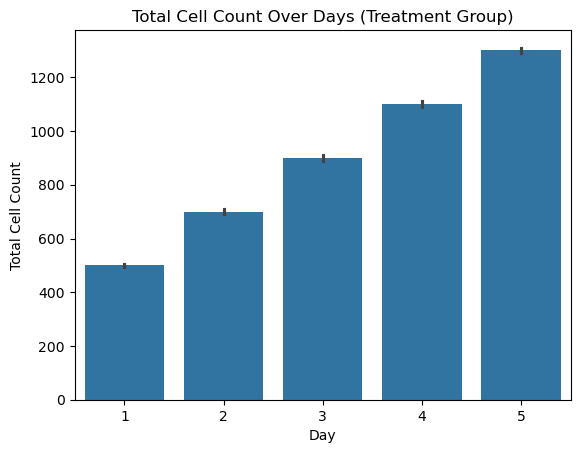

In [21]:
sns.barplot(
    data=df[df['Group'] == 'Treatment'],
    x='Day',
    y='Total_cell_count',
    errorbar='sd'
)

plt.title('Total Cell Count Over Days (Treatment Group)')
plt.xlabel('Day')
plt.ylabel('Total Cell Count')
plt.show()